# Análisis de Ventas - TP1
Exploración de los datos del emprendimiento con **pandas** y visualización con **matplotlib**.

Este notebook carga `ventas.json` (el mismo archivo que usa `main.py`), calcula indicadores
y genera gráficos para entender el comportamiento de las ventas.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import json

with open("ventas.json", "r", encoding="utf-8") as f:
    datos = json.load(f)

df = pd.DataFrame(datos)
df.head()

,producto,categoria,precio,cantidad,total_venta
0,Remera Estampada,Indumentaria,8500.0,5,42500.0
1,Buzo Canguro,Indumentaria,15000.0,3,45000.0
2,Gorra,Accesorios,4500.0,8,36000.0
3,Mochila,Accesorios,22000.0,2,44000.0
4,Termo,Hogar,18000.0,4,72000.0


## 1. Información general del dataset

In [2]:
print(f"Cantidad de registros: {len(df)}")
print(f"Columnas: {list(df.columns)}")
df.info()

Cantidad de registros: 12
Columnas: ['producto', 'categoria', 'precio', 'cantidad', 'total_venta']
<class 'pandas.DataFrame'>
RangeIndex: 12 entries, 0 to 11
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   producto     12 non-null     str    
 1   categoria    12 non-null     str    
 2   precio       12 non-null     float64
 3   cantidad     12 non-null     int64  
 4   total_venta  12 non-null     float64
dtypes: float64(2), int64(1), str(2)
memory usage: 612.0 bytes


## 2. Indicadores generales

In [3]:
ingresos_totales = df["total_venta"].sum()
promedio_venta = df["total_venta"].mean()
venta_maxima = df["total_venta"].max()
venta_minima = df["total_venta"].min()

print(f"Ingresos totales : \${ingresos_totales:,.2f}")
print(f"Promedio por venta : \${promedio_venta:,.2f}")
print(f"Venta más alta : \${venta_maxima:,.2f}")
print(f"Venta más baja : \${venta_minima:,.2f}")

Ingresos totales : \$466,000.00
Promedio por venta : \$38,833.33
Venta más alta : \$72,000.00
Venta más baja : \$18,000.00


<>:6: SyntaxWarning: invalid escape sequence '\$'
<>:7: SyntaxWarning: invalid escape sequence '\$'
<>:8: SyntaxWarning: invalid escape sequence '\$'
<>:9: SyntaxWarning: invalid escape sequence '\$'
<>:6: SyntaxWarning: invalid escape sequence '\$'
<>:7: SyntaxWarning: invalid escape sequence '\$'
<>:8: SyntaxWarning: invalid escape sequence '\$'
<>:9: SyntaxWarning: invalid escape sequence '\$'
/tmp/ipykernel_178/2547798865.py:6: SyntaxWarning: invalid escape sequence '\$'
  print(f"Ingresos totales : \${ingresos_totales:,.2f}")
/tmp/ipykernel_178/2547798865.py:7: SyntaxWarning: invalid escape sequence '\$'
  print(f"Promedio por venta : \${promedio_venta:,.2f}")
/tmp/ipykernel_178/2547798865.py:8: SyntaxWarning: invalid escape sequence '\$'
  print(f"Venta más alta : \${venta_maxima:,.2f}")
/tmp/ipykernel_178/2547798865.py:9: SyntaxWarning: invalid escape sequence '\$'
  print(f"Venta más baja : \${venta_minima:,.2f}")


## 3. Producto más vendido (por cantidad)

In [4]:
cantidad_por_producto = df.groupby("producto")["cantidad"].sum().sort_values(ascending=False)
cantidad_por_producto

producto
Gorra               13
Remera Estampada    11
Taza                10
Termo                5
Buzo Canguro         5
Pantalón Jogger      4
Mochila              3
Name: cantidad, dtype: int64

## 4. Ingresos por categoría

In [5]:
ingresos_por_categoria = df.groupby("categoria")["total_venta"].sum().sort_values(ascending=False)
ingresos_por_categoria

categoria
Indumentaria    216500.0
Hogar           125000.0
Accesorios      124500.0
Name: total_venta, dtype: float64

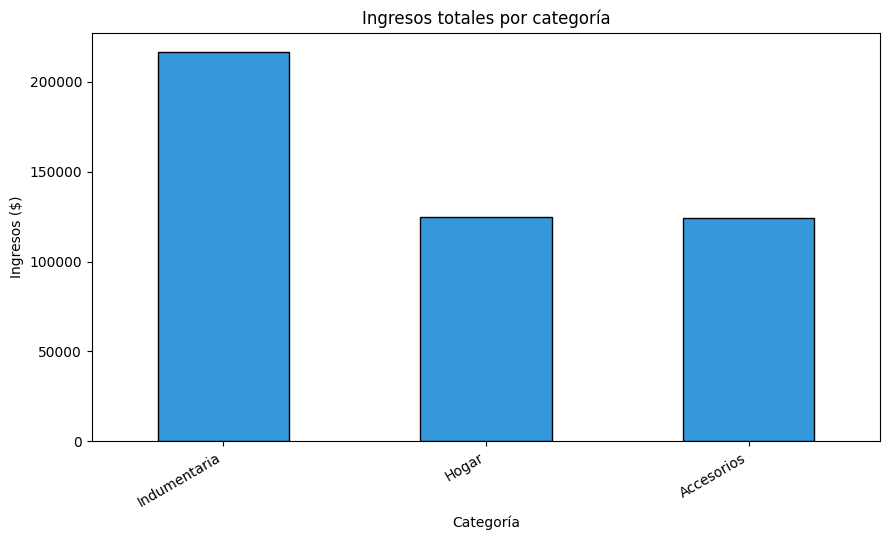

In [6]:
plt.figure(figsize=(9, 5.5))
ingresos_por_categoria.plot(kind="bar", color="#3498db", edgecolor="black")
plt.title("Ingresos totales por categoría")
plt.xlabel("Categoría")
plt.ylabel("Ingresos ($)")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.savefig("ventas_categoria.png")
plt.show()

## 5. Participación de cada producto en los ingresos totales

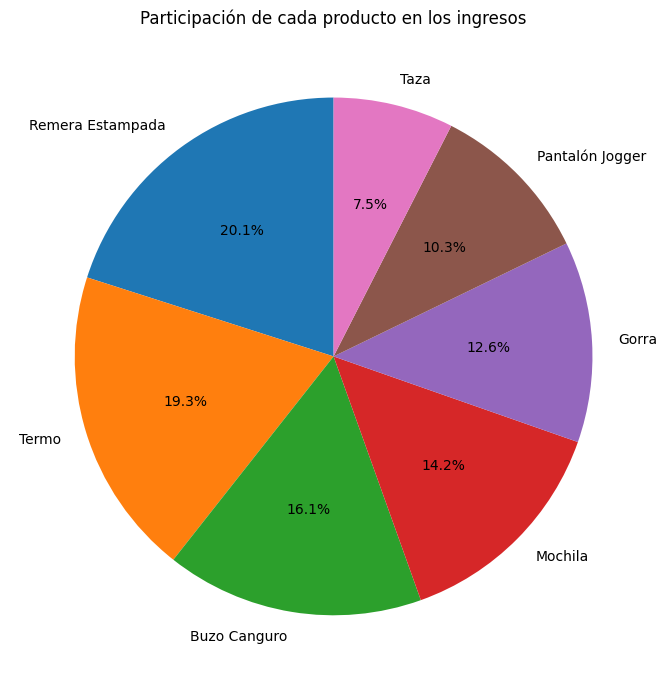

In [7]:
ingresos_por_producto = df.groupby("producto")["total_venta"].sum().sort_values(ascending=False)

plt.figure(figsize=(7, 7))
plt.pie(ingresos_por_producto, labels=ingresos_por_producto.index, autopct="%1.1f%%", startangle=90)
plt.title("Participación de cada producto en los ingresos")
plt.tight_layout()
plt.show()

## 6. Conclusiones

- La categoría **Indumentaria** concentra la mayor parte de los ingresos del emprendimiento,
  por encima de Accesorios y Hogar.
- El producto con mayor volumen de unidades vendidas es la **Gorra**, aunque no es el que más
  ingresos genera: eso muestra que "más vendido" y "más rentable" no siempre coinciden.
- El promedio de venta ronda los \$38.800, lo que sirve como referencia para detectar operaciones
  atípicas (muy por arriba o por debajo de ese valor).
- Estos indicadores se recalculan automáticamente cada vez que se agregan ventas nuevas desde
  `main.py`, por lo que este análisis puede repetirse en cualquier momento sobre datos actualizados.